# Abnormality distribution by kernel and scanner

Run this **right after `make_worklist.py`** -- it needs no images, only what that script already downloaded
(the CT-RATE metadata, the label CSVs, and the run's `worklist.csv`) plus the sharp / soft table
`configs/kernel_classes.csv`.

It answers four questions *before* the long download:

1. **What does the run actually take?** How many volumes per pool, kernel class and scanner, and how many train scans are
   skipped because they have no reconstruction of the wanted kernel.
2. **Do the labels depend on the scanner or the kernel?** If a finding is much more common on one scanner, a model can
   learn "this looks like scanner X" instead of the finding (shortcut learning) -- and a model trained on one kernel is
   partly a model of one group of scanners.
3. **Are the skipped scans different from the kept ones?** Skipping them is only harmless if they are not a distinct group.
4. **How balanced are the train / val / test splits?** Share of each finding, kernel and scanner in each split (section 6).

The labels are CT-RATE's *predicted* labels (parsed from the radiology reports by a model), not human-checked ground truth.
Labels belong to a scan, so both reconstructions of a scan carry the same labels; what differs between kernels is *which
scans* have that kernel.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

# run from the repository root, wherever the notebook was opened
root = Path.cwd().resolve()
while not (root / "configs" / "preprocessing.yaml").exists() and root != root.parent:
    root = root.parent
os.chdir(root)

from ct_preprocessing.config import load_config
from ct_preprocessing.ingest.ctrate import load_metadata
from ct_preprocessing.ingest.labels import label_column, load_ctrate_labels
from ct_preprocessing.ingest.worklist import read_worklist
from ct_preprocessing.kernels import add_kernel_columns, load_kernel_table
from ct_preprocessing.manifest import parse_volume_id, strip_nifti_ext
from ct_preprocessing.runs import list_runs, resolve_run

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

## 1. Pick the run

`RUN = None` uses the only run on disk; with several, name one. `CONFIG` is the settings file the scripts used.

In [2]:
CONFIG = "configs/preprocessing.yaml"
SOURCE = "ctrate"
RUN = "train-sharp-5800"  # e.g. "train-sharp"

cfg = load_config(CONFIG)
print("runs of", SOURCE + ":", list_runs(cfg.paths, SOURCE) or "none yet -- run make_worklist.py first")
run = resolve_run(cfg.paths, SOURCE, RUN)
worklist = read_worklist(run.worklist_path)
table = load_kernel_table(cfg.paths.kernel_table)
train_kernel = (pd.read_json(run.info_path, typ="series").get("settings") or {}).get("train_kernel", "sharp")
print(f"run {run.name!r}: {len(worklist)} volumes in {worklist.chunk.nunique()} chunks; train kernel = {train_kernel}")

runs of ctrate: ['train-sharp-5800']
run 'train-sharp-5800': 10045 volumes in 252 chunks; train kernel = sharp


In [3]:
meta = load_metadata(cfg.paths)
labels = load_ctrate_labels(cfg.paths)
if labels is None:
    raise SystemExit("no label files in " + cfg.paths.metadata_dir + " -- make_worklist.py downloads them (or copy "
                     "train_predicted_labels.csv / valid_predicted_labels.csv there by hand)")
label_cols = [c for c in labels.columns if c != "volume_id"]
label_names = {c: label_column(c) for c in label_cols}

# every train / valid volume of the metadata, with its scanner, kernel and kernel class
frames = []
for pool, df in meta.items():
    ids = df["VolumeName"].map(strip_nifti_ext)
    parsed = pd.DataFrame([parse_volume_id(v) for v in ids])
    parsed["manufacturer"], parsed["_kernel"] = df["Manufacturer"].values, df["ConvolutionKernel"].values
    frames.append(parsed)
catalog = add_kernel_columns(pd.concat(frames, ignore_index=True), table, manufacturer_col="manufacturer", kernel_col="_kernel")
catalog = catalog.drop(columns="_kernel").merge(labels, on="volume_id", how="left")
print(f"{len(catalog)} volumes in the metadata; {catalog[label_cols[0]].notna().sum()} have labels")

50188 volumes in the metadata; 50188 have labels


## 2. What the run takes

The worklist always takes the whole valid pool (the test set, every reconstruction) and one reconstruction of the chosen kernel
per train scan.

In [4]:
wl = worklist.merge(labels, on="volume_id", how="left")
print("volumes by pool and kernel class")
display(pd.crosstab(wl.source_split, wl.kernel_class, margins=True))
print("volumes by scanner and kernel class")
display(pd.crosstab(wl.manufacturer, wl.kernel_class, margins=True))

volumes by pool and kernel class


kernel_class,other,sharp,soft,All
source_split,,,,
train,0,7006,0,7006
valid,36,1543,1460,3039
All,36,8549,1460,10045


volumes by scanner and kernel class


kernel_class,other,sharp,soft,All
manufacturer,,,,
PNMS,0,702,14,716
Philips,36,5131,954,6121
SIEMENS,0,331,61,392
Siemens Healthineers,0,2385,431,2816
All,36,8549,1460,10045


In [5]:
train = catalog[catalog.source_split == "train"]
scans = train.groupby(["patient_id", "scan_id"]).agg(
    has_wanted=("kernel_class", lambda s: (s == train_kernel).any()),
    n_recon=("volume_id", "size"),
    manufacturer=("manufacturer", "first"),
).reset_index()
skipped = scans[~scans.has_wanted]
patients_with_none = int((~scans.groupby("patient_id").has_wanted.any()).sum())
print(f"{len(scans)} train scans; {int(scans.has_wanted.sum())} have a {train_kernel} reconstruction, "
      f"{len(skipped)} are skipped ({100 * len(skipped) / len(scans):.1f}%) -- {patients_with_none} patients have no {train_kernel} scan at all")
print("\nskipped scans by scanner (share of that scanner's scans):")
share = (skipped.manufacturer.value_counts() / scans.manufacturer.value_counts()).dropna().mul(100).round(1)
display(pd.DataFrame({"skipped": skipped.manufacturer.value_counts(), "of_scans": scans.manufacturer.value_counts(), "percent": share}).dropna())

24128 train scans; 23726 have a sharp reconstruction, 402 are skipped (1.7%) -- 283 patients have no sharp scan at all

skipped scans by scanner (share of that scanner's scans):


,skipped,of_scans,percent
manufacturer,,,
PNMS,7,1937,0.4
Philips,224,14218,1.6
SIEMENS,8,1069,0.7
Siemens Healthineers,163,6904,2.4


## 3. Do the labels depend on the scanner?

Prevalence (percent of scans with the finding) in the train volumes the run takes, per scanner. A large spread means the
scanner and the label go together.

In [6]:
taken = wl[wl.source_split == "train"].copy()
by_scanner = taken.groupby("manufacturer")[label_cols].mean().mul(100).round(1)
by_scanner["scans"] = taken.groupby("manufacturer").size()
by_scanner = by_scanner[by_scanner.scans >= 30]  # a few scans say nothing
overall = taken[label_cols].mean().mul(100).round(1)

spread = (by_scanner[label_cols].max() - by_scanner[label_cols].min()).round(1)
summary = pd.DataFrame({"overall_%": overall, "lowest_scanner_%": by_scanner[label_cols].min(),
                        "highest_scanner_%": by_scanner[label_cols].max(), "spread": spread}).sort_values("spread", ascending=False)
display(summary)
print("scanners compared:", ", ".join(f"{m} ({n})" for m, n in by_scanner.scans.items()))

,overall_%,lowest_scanner_%,highest_scanner_%,spread
Atelectasis,25.4,18.4,39.9,21.5
Coronary artery wall calcification,25.4,13.9,33.9,20.0
Pleural effusion,11.4,6.8,26.6,19.8
Medical material,11.4,7.5,25.1,17.6
Arterial wall calcification,28.1,18.9,36.5,17.6
Lung opacity,36.2,24.1,38.2,14.1
Lymphadenopathy,25.2,15.6,29.2,13.6
Peribronchial thickening,10.8,3.6,15.1,11.5
Emphysema,19.4,18.0,29.5,11.5
Consolidation,16.6,10.9,20.3,9.4


scanners compared: PNMS (576), Philips (4193), SIEMENS (271), Siemens Healthineers (1966)


In [7]:
from scipy.stats import chi2_contingency

rows = []
for col in label_cols:
    counts = taken.dropna(subset=[col]).groupby("manufacturer")[col].agg(["sum", "count"])
    counts = counts[counts["count"] >= 30]
    table2 = np.array([counts["sum"], counts["count"] - counts["sum"]])
    p = chi2_contingency(table2)[1] if table2.shape[1] > 1 and table2.min() >= 0 else np.nan
    rows.append({"label": col, "p_value": p, "spread_points": float(spread[col])})
tests = pd.DataFrame(rows).sort_values("p_value")
tests["flag"] = np.where((tests.p_value < 0.001) & (tests.spread_points >= 5), "depends on scanner", "")
display(tests.reset_index(drop=True))
print(f"{(tests.flag != '').sum()} of {len(tests)} labels differ clearly between scanners "
      "(p < 0.001 and at least 5 percentage points) -- with this many scans a small spread can be significant, so read the spread too")

,label,p_value,spread_points,flag
0,Coronary artery wall calcification,2.062627e-17,20.0,depends on scanner
1,Pleural effusion,5.406548e-16,19.8,depends on scanner
2,Peribronchial thickening,6.866206e-16,11.5,depends on scanner
3,Atelectasis,3.690792e-14,21.5,depends on scanner
4,Medical material,6.484750e-13,17.6,depends on scanner
5,Arterial wall calcification,2.269303e-10,17.6,depends on scanner
6,Lung opacity,9.216623e-10,14.1,depends on scanner
7,Lymphadenopathy,7.761417e-08,13.6,depends on scanner
8,Emphysema,1.624967e-05,11.5,depends on scanner
9,Consolidation,2.581500e-04,9.4,depends on scanner


10 of 18 labels differ clearly between scanners (p < 0.001 and at least 5 percentage points) -- with this many scans a small spread can be significant, so read the spread too


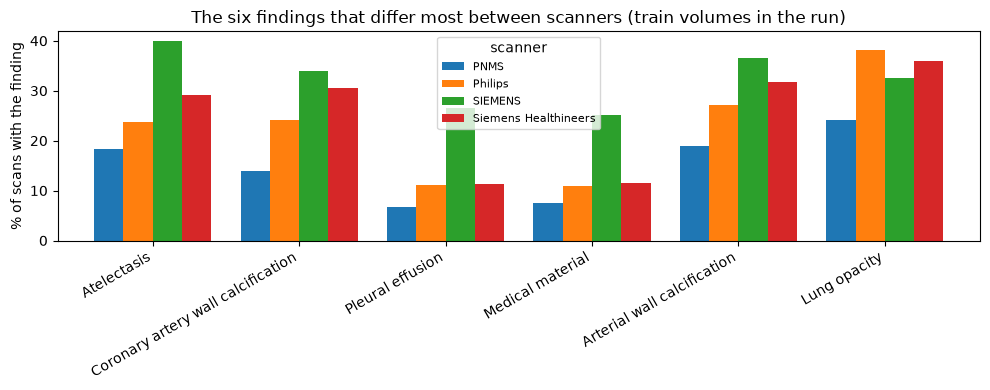

In [8]:
import matplotlib.pyplot as plt

top = list(summary.index[:6])
ax = by_scanner[top].T.plot.bar(figsize=(10, 4), width=0.8)
ax.set_ylabel("% of scans with the finding")
ax.set_title("The six findings that differ most between scanners (train volumes in the run)")
ax.legend(title="scanner", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4. Are the skipped scans different from the kept ones?

If scans without the wanted kernel have a different mix of findings, skipping them changes what the model sees.

In [9]:
lab_train = train.drop_duplicates(["patient_id", "scan_id"]).merge(scans[["patient_id", "scan_id", "has_wanted"]], on=["patient_id", "scan_id"])
cmp = lab_train.groupby("has_wanted")[label_cols].mean().T.mul(100).round(1)
cmp.columns = ["skipped_%", "kept_%"] if list(cmp.columns) == [False, True] else cmp.columns
cmp["difference"] = (cmp.iloc[:, 0] - cmp.iloc[:, 1]).round(1)
display(cmp.sort_values("difference"))
print(f"{len(skipped)} skipped scans against {int(scans.has_wanted.sum())} kept: a difference of several points on a finding means "
      "the skipped scans are a distinct group, but they are a small share of the data")

,skipped_%,kept_%,difference
Pulmonary fibrotic sequela,23.4,26.8,-3.4
Bronchiectasis,7.2,10.0,-2.8
Lung nodule,43.5,45.5,-2.0
Peribronchial thickening,8.5,10.4,-1.9
Emphysema,18.7,19.4,-0.7
Hiatal hernia,14.4,14.2,0.2
Lymphadenopathy,26.1,25.3,0.8
Lung opacity,37.6,36.6,1.0
Consolidation,19.4,17.5,1.9
Pericardial effusion,9.0,7.0,2.0


402 skipped scans against 23726 kept: a difference of several points on a finding means the skipped scans are a distinct group, but they are a small share of the data


## 5. The test pool, by kernel

The test pool takes every reconstruction, so a model can be tested on sharp and on soft. Labels are per scan, so the two kernels
carry the same labels; what to look at is how many volumes and scanners each view has.

In [10]:
test = catalog[catalog.source_split == "valid"]
print("test volumes:", len(test), "| scans:", len(test.drop_duplicates(["patient_id", "scan_id"])), "| patients:", test.patient_id.nunique())
display(pd.crosstab(test.manufacturer, test.kernel_class, margins=True))
print("prevalence (% of volumes) by kernel class -- labels are per scan, so a gap here only means the two kernels sit on different scans")
display(test.groupby("kernel_class")[label_cols].mean().T.mul(100).round(1))

test volumes: 3039 | scans: 1564 | patients: 1304


kernel_class,other,sharp,soft,All
manufacturer,,,,
PNMS,0,126,14,140
Philips,36,938,954,1928
SIEMENS,0,60,61,121
Siemens Healthineers,0,419,431,850
All,36,1543,1460,3039


prevalence (% of volumes) by kernel class -- labels are per scan, so a gap here only means the two kernels sit on different scans


kernel_class,other,sharp,soft
Medical material,16.7,9.9,10.6
Arterial wall calcification,33.3,27.8,29.2
Cardiomegaly,25.0,10.4,10.6
Pericardial effusion,25.0,7.1,7.4
Coronary artery wall calcification,16.7,24.5,26.1
Hiatal hernia,0.0,14.0,13.8
Lymphadenopathy,41.7,25.3,26.2
Emphysema,25.0,19.6,19.8
Atelectasis,25.0,23.1,23.8
Lung nodule,25.0,44.8,45.3


In [11]:
manifest_file = run.manifest_path
if manifest_file.exists():
    manifest = pd.read_csv(manifest_file)
    print("manifest of this run:", len(manifest), "volumes")
    display(pd.crosstab(manifest.split, manifest.kernel_class, margins=True))
else:
    print("no manifest yet -- it appears after ingest.py and merge_manifests.py")

manifest of this run: 10045 volumes


kernel_class,other,sharp,soft,All
split,,,,
excluded,0,2,1,3
test,36,1542,1459,3037
train,0,5827,0,5827
val,0,1178,0,1178
All,36,8549,1460,10045


## 6. Class balance in train / val / test

Sections 2-5 look at the worklist and the official pools. This section looks at the **splits the model really uses**, from the run's
`manifest.csv` (frozen after ingest + QC, made by patient: `train` and `val` come from the train pool, `test` is the whole valid pool,
`excluded` are volumes that failed QC and are left out here).

Each view is a table plus a chart. Percentages are *of the split's volumes*, because volumes are what the model sees and is scored on
(in the test split a scan has one volume per reconstruction, so both kernels of a scan count).

In [12]:
import matplotlib.pyplot as plt

SPLITS = ["train", "val", "test"]  # the frozen patient-level splits; "excluded" (failed QC) is in none of them
SPLIT_COLOR = {"train": "#4C78A8", "val": "#F58518", "test": "#54A24B"}
CLASS_COLOR = {"sharp": "#E45756", "soft": "#72B7B2", "other": "#8C8C8C"}

if not run.manifest_path.exists():
    raise RuntimeError("no manifest yet -- the splits live in it, so run ingest.py and merge_manifests.py first")
man = pd.read_csv(run.manifest_path)
print("volumes by split (excluded = failed QC, left out below):", man.split.value_counts().to_dict())
man = man[man.split.isin(SPLITS)].copy()
man["kernel"] = man.kernel.fillna("unknown")
man["scan_key"] = man.patient_id + "/" + man.scan_id
lab_cols = [label_names[c] for c in label_cols]  # the manifest column of every finding
nice = {label_names[c]: c for c in label_cols}   # ... and its readable name
assert man[lab_cols].notna().all().all(), "the manifest has volumes without labels"


def pct_of_split(ct):
    """Counts (rows = split) -> percent of each split's volumes."""
    return ct.div(ct.sum(axis=1), axis=0).mul(100)


def stacked_bars(ax, pct, colors, title):
    """One horizontal bar per split, cut into the groups of `pct`."""
    left = np.zeros(len(pct))
    for col in pct.columns:
        vals = pct[col].to_numpy()
        ax.barh(pct.index, vals, left=left, label=col, color=colors[col], edgecolor="white")
        for y, (l, v) in enumerate(zip(left, vals)):
            if v >= 4:
                ax.text(l + v / 2, y, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=8)
        left += vals
    ax.set_xlim(0, 100)
    ax.invert_yaxis()
    ax.set_xlabel("% of the split's volumes")
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=min(len(pct.columns), 5), loc="upper center", bbox_to_anchor=(0.5, -0.2), frameon=False)

volumes by split (excluded = failed QC, left out below): {'train': 5827, 'test': 3037, 'val': 1178, 'excluded': 3}


### 6.1 Split sizes, kernel class and scanner

Are the three splits the same kind of data? `train` and `val` hold only the wanted kernel by construction; `test` has both.

,volumes,scans,patients,% of volumes
split,,,,
train,5827,5827,4799,58.0
val,1178,1178,1000,11.7
test,3037,1564,1304,30.2


volumes by kernel class: count, then % of the split


volumes             % of split             
kernel_class   other sharp  soft      other  sharp  soft
split                                                   
train              0  5827     0        0.0  100.0   0.0
val                0  1178     0        0.0  100.0   0.0
test              36  1542  1459        1.2   50.8  48.0

volumes by scanner: count, then % of the split


volumes                                      % of split                                     
manufacturer    PNMS Philips SIEMENS Siemens Healthineers       PNMS Philips SIEMENS Siemens Healthineers
split                                                                                                    
train            479    3476     230                 1642        8.2    59.7     3.9                 28.2
val               97     716      41                  324        8.2    60.8     3.5                 27.5
test             140    1927     120                  850        4.6    63.5     4.0                 28.0

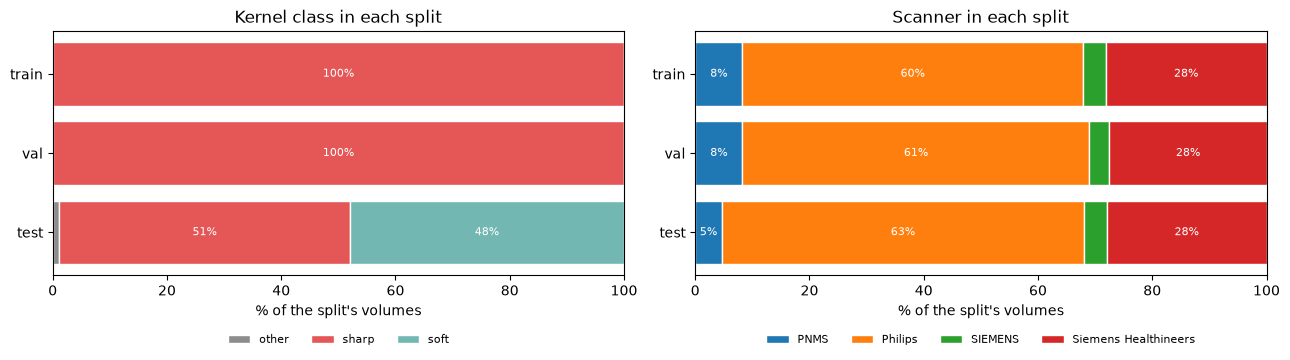

In [13]:
overview = man.groupby("split").agg(volumes=("volume_id", "size"), scans=("scan_key", "nunique"),
                                    patients=("patient_id", "nunique")).reindex(SPLITS)
overview["% of volumes"] = (100 * overview.volumes / overview.volumes.sum()).round(1)
display(overview)

kernel_ct = pd.crosstab(man.split, man.kernel_class).reindex(SPLITS)
scanner_ct = pd.crosstab(man.split, man.manufacturer).reindex(SPLITS)
for name, ct in [("kernel class", kernel_ct), ("scanner", scanner_ct)]:
    print(f"volumes by {name}: count, then % of the split")
    display(pd.concat({"volumes": ct, "% of split": pct_of_split(ct).round(1)}, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
stacked_bars(axes[0], pct_of_split(kernel_ct), CLASS_COLOR, "Kernel class in each split")
stacked_bars(axes[1], pct_of_split(scanner_ct), dict(zip(scanner_ct.columns, plt.cm.tab10.colors)), "Scanner in each split")
plt.tight_layout()
plt.show()

### 6.2 Convolution kernels

The raw `ConvolutionKernel` names behind the sharp / soft classes, as a share of each split. Kernels that train never saw
(for example `B`, `Br40f`) show up only in test -- that is the cross-kernel part of the evaluation.

split,class,train n,val n,test n,train %,val %,test %
kernel,,,,,,,
YA,sharp,2923,590,779,50.2,50.1,25.7
Br60f,sharp,1003,202,239,17.2,17.1,7.9
Bl56f,sharp,638,122,180,10.9,10.4,5.9
B,soft,0,0,851,0.0,0.0,28.0
EA,sharp,478,97,125,8.2,8.2,4.1
L,sharp,311,60,93,5.3,5.1,3.1
Br40f,soft,0,0,425,0.0,0.0,14.0
YB,sharp,237,66,65,4.1,5.6,2.1
Bl57d,sharp,217,41,59,3.7,3.5,1.9


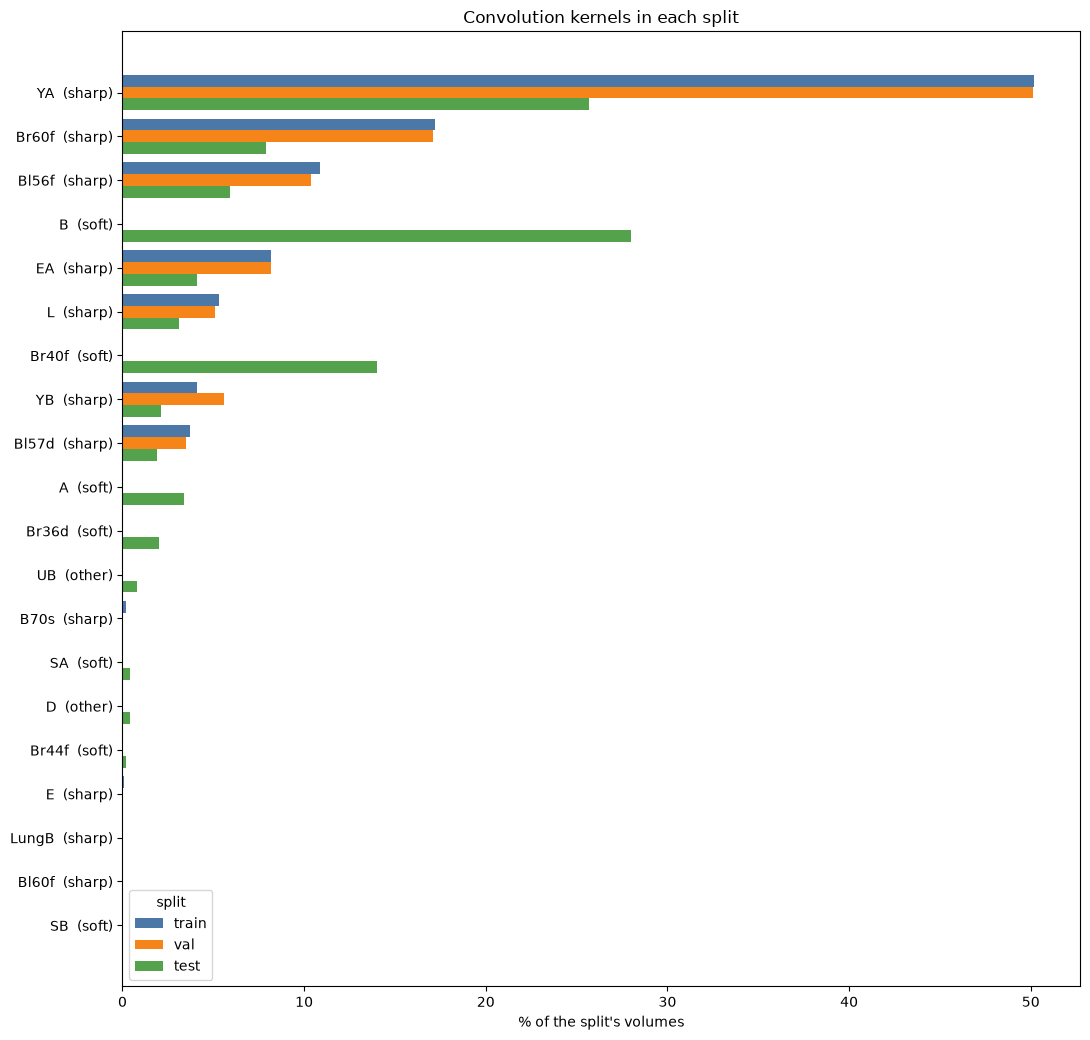

In [14]:
by_kernel = pd.crosstab(man.kernel, man.split).reindex(columns=SPLITS)
kernels = by_kernel.add_suffix(" n").join(by_kernel.div(by_kernel.sum()).mul(100).round(1).add_suffix(" %"))
kernels.insert(0, "class", man.drop_duplicates("kernel").set_index("kernel").kernel_class.reindex(kernels.index))
kernels = kernels.assign(total=by_kernel.sum(axis=1)).sort_values("total", ascending=False).drop(columns="total")
display(kernels)

fig, ax = plt.subplots(figsize=(11, 0.45 * len(kernels) + 1.5))
y, h = np.arange(len(kernels)), 0.27
for k, s in enumerate(SPLITS):
    ax.barh(y + (k - 1) * h, kernels[f"{s} %"], h, label=s, color=SPLIT_COLOR[s])
ax.set_yticks(y, [f"{k}  ({c})" for k, c in zip(kernels.index, kernels["class"])])
ax.invert_yaxis()
ax.set_xlabel("% of the split's volumes")
ax.set_title("Convolution kernels in each split")
ax.legend(title="split")
plt.tight_layout()
plt.show()

### 6.3 How common is each finding in each split

Left: percent of volumes that carry the finding. Right: how far val and test are from train, in percentage points (a bar to the
right means more common than in train). `pos_weight` is the number of negatives per positive in train, ready for
`BCEWithLogitsLoss(pos_weight=...)`; the rare findings at the bottom are the ones to watch for.

,train %,val %,test %,all %,train n,val n,test n,val - train,test - train,pos_weight
Lung nodule,46.6,44.1,44.7,45.8,2717,519,1359,-2.6,-1.9,1.14
Lung opacity,36.1,36.2,39.0,37.0,2106,426,1183,0.0,2.8,1.77
Arterial wall calcification,28.6,25.6,28.5,28.2,1669,301,866,-3.1,-0.1,2.49
Pulmonary fibrotic sequela,26.3,26.3,27.4,26.6,1535,310,831,-0.0,1.0,2.80
Coronary artery wall calcification,25.9,23.2,25.2,25.4,1510,273,764,-2.7,-0.8,2.86
Atelectasis,25.6,24.6,23.4,24.8,1491,290,712,-1.0,-2.1,2.91
Lymphadenopathy,25.4,24.4,25.9,25.5,1482,287,788,-1.1,0.5,2.93
Emphysema,19.5,18.8,19.7,19.5,1136,222,599,-0.6,0.2,4.13
Consolidation,16.4,17.6,19.1,17.4,957,207,581,1.1,2.7,5.09
Hiatal hernia,14.1,13.5,13.7,13.9,822,159,416,-0.6,-0.4,6.09


percent of the split's volumes that carry the finding; 'val - train' and 'test - train' are percentage points; pos_weight = negatives per positive in train
largest train-vs-test gap: Lung opacity (+2.8 points)


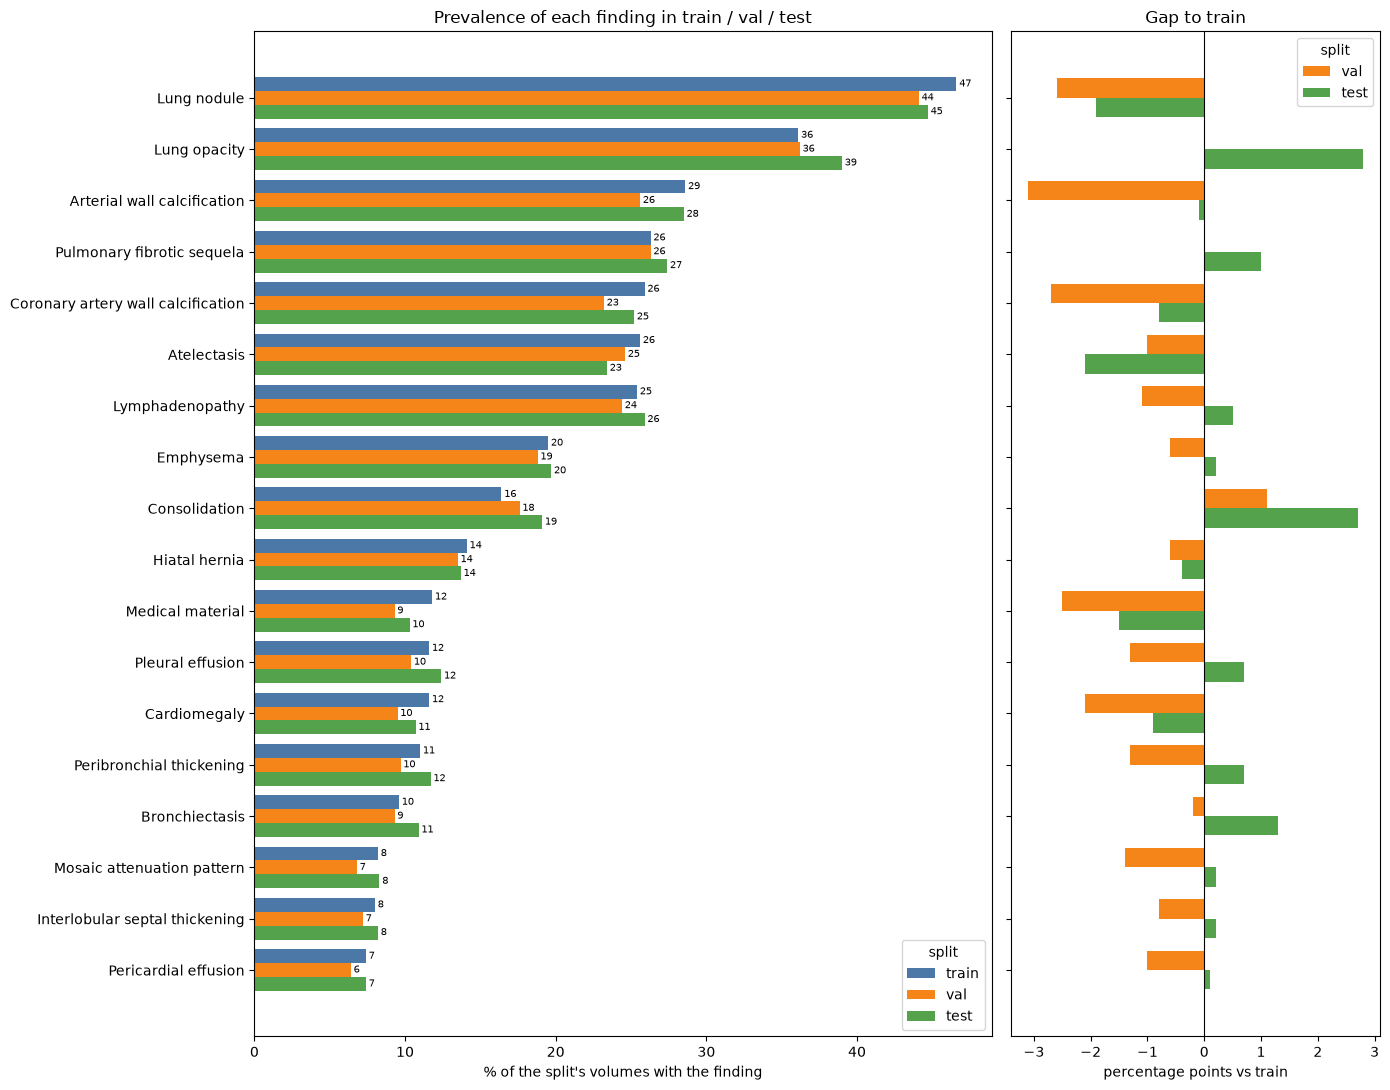

In [15]:
pos = man.groupby("split")[lab_cols].sum().T.reindex(columns=SPLITS)
prev = man.groupby("split")[lab_cols].mean().T.mul(100).reindex(columns=SPLITS)
prevalence = pd.DataFrame({
    "train %": prev.train, "val %": prev.val, "test %": prev.test,
    "all %": man[lab_cols].mean().mul(100),
    "train n": pos.train, "val n": pos.val, "test n": pos.test,
    "val - train": prev.val - prev.train, "test - train": prev.test - prev.train,
    "pos_weight": (100 - prev.train) / prev.train,  # negatives per positive in train, e.g. for BCEWithLogitsLoss
}).rename(index=nice).sort_values("train %", ascending=False)
prevalence = prevalence.round({"train %": 1, "val %": 1, "test %": 1, "all %": 1, "val - train": 1, "test - train": 1, "pos_weight": 2})
display(prevalence)
print("percent of the split's volumes that carry the finding; 'val - train' and 'test - train' are percentage points; "
      "pos_weight = negatives per positive in train")
print(f"largest train-vs-test gap: {prevalence['test - train'].abs().idxmax()} ({prevalence['test - train'].loc[prevalence['test - train'].abs().idxmax()]:+.1f} points)")

order = prevalence.index[::-1]  # barh draws the first row at the bottom
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 0.5 * len(order) + 2), sharey=True, gridspec_kw={"width_ratios": [2, 1]})
y, h = np.arange(len(order)), 0.27
for k, s in enumerate(SPLITS):
    bars = a1.barh(y + (1 - k) * h, prevalence.loc[order, f"{s} %"], h, label=s, color=SPLIT_COLOR[s])
    a1.bar_label(bars, fmt="%.0f", fontsize=7, padding=2)
a1.set_yticks(y, order)
a1.set_xlabel("% of the split's volumes with the finding")
a1.set_title("Prevalence of each finding in train / val / test")
a1.legend(title="split", loc="lower right")
for k, s in enumerate(["val", "test"]):
    a2.barh(y + (0.5 - k) * h * 1.4, prevalence.loc[order, f"{s} - train"], h * 1.4, label=s, color=SPLIT_COLOR[s])
a2.axvline(0, color="black", lw=0.8)
a2.set_xlabel("percentage points vs train")
a2.set_title("Gap to train")
a2.legend(title="split")
plt.tight_layout()
plt.show()

### 6.4 The same, by split and kernel class

Only groups with at least 100 volumes are shown (the 36 `other`-kernel test volumes are too few to read a percentage from).
If `test sharp` and `test soft` are close, the finding does not depend on the kernel; if `test` is far from `train`, the gap is a
change of patients, not of kernel.

,train sharp (n=5827),val sharp (n=1178),test sharp (n=1542),test soft (n=1459)
Lung nodule,46.6,44.1,44.7,45.2
Lung opacity,36.1,36.2,38.6,39.9
Arterial wall calcification,28.6,25.6,27.8,29.1
Pulmonary fibrotic sequela,26.3,26.3,27.2,27.6
Coronary artery wall calcification,25.9,23.2,24.5,26.0
Atelectasis,25.6,24.6,23.1,23.8
Lymphadenopathy,25.4,24.4,25.4,26.2
Emphysema,19.5,18.8,19.6,19.7
Consolidation,16.4,17.6,18.9,19.6
Hiatal hernia,14.1,13.5,13.9,13.8


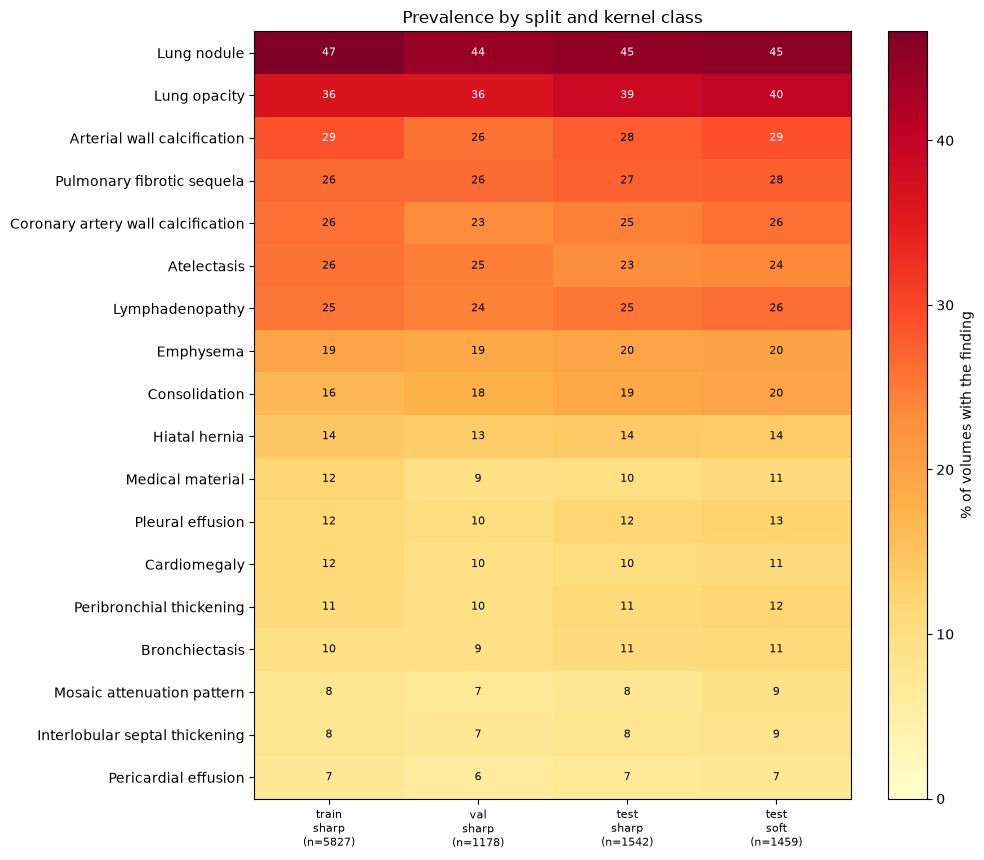

In [16]:
groups = man.groupby(["split", "kernel_class"])
sizes = groups.size()
sizes = sizes[sizes >= 100].reindex([(s, k) for s in SPLITS for k in ["sharp", "soft", "other"]]).dropna().astype(int)  # a few volumes say nothing
grp_prev = groups[lab_cols].mean().mul(100).loc[sizes.index].T.rename(index=nice)
grp_prev.columns = [f"{s}\n{k}\n(n={sizes[(s, k)]})" for s, k in grp_prev.columns]
grp_prev = grp_prev.loc[prevalence.index]
display(grp_prev.round(1).rename(columns=lambda c: c.replace("\n", " ")))

fig, ax = plt.subplots(figsize=(1.3 * grp_prev.shape[1] + 5, 0.4 * len(grp_prev) + 1.5))
im = ax.imshow(grp_prev.to_numpy(), cmap="YlOrRd", aspect="auto", vmin=0)
ax.set_xticks(range(grp_prev.shape[1]), grp_prev.columns, fontsize=8)
ax.set_yticks(range(len(grp_prev)), grp_prev.index)
for i in range(grp_prev.shape[0]):
    for j in range(grp_prev.shape[1]):
        v = grp_prev.iat[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if v > 0.6 * grp_prev.to_numpy().max() else "black")
fig.colorbar(im, ax=ax, label="% of volumes with the finding")
ax.set_title("Prevalence by split and kernel class")
plt.tight_layout()
plt.show()

### 6.5 How many findings does a volume carry?

This is a multi-label problem: a volume with no finding and a volume with five look very different to a model. The `5+` bar groups
everything from five findings up.

% of split                              
findings per volume          0     1     2     3     4    5+
split                                                       
train                     11.6  17.3  16.3  13.5   9.7  31.6
val                       13.0  18.4  17.1  12.2  10.6  28.7
test                      11.4  16.8  15.7  13.4  11.4  31.3

,mean,median,max
split,,,
train,3.44,3.0,13
val,3.23,3.0,14
test,3.47,3.0,12


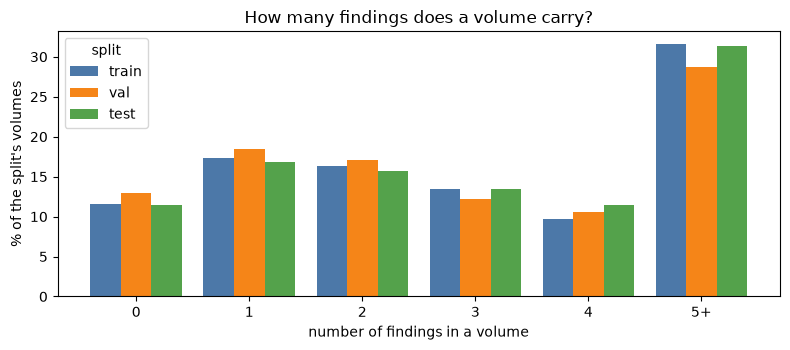

In [17]:
n_pos = man[lab_cols].sum(axis=1).clip(upper=5).map(lambda n: "5+" if n >= 5 else str(int(n)))
per_vol = pct_of_split(pd.crosstab(man.split, n_pos).reindex(SPLITS)).round(1)
per_vol.columns.name = "findings per volume"
display(pd.concat({"% of split": per_vol, }, axis=1))
stats = man.assign(n=man[lab_cols].sum(axis=1)).groupby("split").n.agg(mean="mean", median="median", max="max").reindex(SPLITS).round(2)
display(stats)

fig, ax = plt.subplots(figsize=(8, 3.6))
x, w = np.arange(per_vol.shape[1]), 0.27
for k, s in enumerate(SPLITS):
    ax.bar(x + (k - 1) * w, per_vol.loc[s], w, label=s, color=SPLIT_COLOR[s])
ax.set_xticks(x, per_vol.columns)
ax.set_xlabel("number of findings in a volume")
ax.set_ylabel("% of the split's volumes")
ax.set_title("How many findings does a volume carry?")
ax.legend(title="split")
plt.tight_layout()
plt.show()

## 6. Class balance in train / val / test

Sections 2-5 look at the worklist and the official pools. This section looks at the **splits the model really uses**, from the run's
`manifest.csv` (frozen after ingest + QC, made by patient: `train` and `val` come from the train pool, `test` is the whole valid pool,
`excluded` are volumes that failed QC and are left out here).

Each view is a table plus a chart. Percentages are *of the split's volumes*, because volumes are what the model sees and is scored on
(in the test split a scan has one volume per reconstruction, so both kernels of a scan count).

In [12]:
import matplotlib.pyplot as plt

SPLITS = ["train", "val", "test"]  # the frozen patient-level splits; "excluded" (failed QC) is in none of them
SPLIT_COLOR = {"train": "#4C78A8", "val": "#F58518", "test": "#54A24B"}
CLASS_COLOR = {"sharp": "#E45756", "soft": "#72B7B2", "other": "#8C8C8C"}

if not run.manifest_path.exists():
    raise RuntimeError("no manifest yet -- the splits live in it, so run ingest.py and merge_manifests.py first")
man = pd.read_csv(run.manifest_path)
print("volumes by split (excluded = failed QC, left out below):", man.split.value_counts().to_dict())
man = man[man.split.isin(SPLITS)].copy()
man["kernel"] = man.kernel.fillna("unknown")
man["scan_key"] = man.patient_id + "/" + man.scan_id
lab_cols = [label_names[c] for c in label_cols]  # the manifest column of every finding
nice = {label_names[c]: c for c in label_cols}   # ... and its readable name
assert man[lab_cols].notna().all().all(), "the manifest has volumes without labels"


def pct_of_split(ct):
    """Counts (rows = split) -> percent of each split's volumes."""
    return ct.div(ct.sum(axis=1), axis=0).mul(100)


def stacked_bars(ax, pct, colors, title):
    """One horizontal bar per split, cut into the groups of `pct`."""
    left = np.zeros(len(pct))
    for col in pct.columns:
        vals = pct[col].to_numpy()
        ax.barh(pct.index, vals, left=left, label=col, color=colors[col], edgecolor="white")
        for y, (l, v) in enumerate(zip(left, vals)):
            if v >= 4:
                ax.text(l + v / 2, y, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=8)
        left += vals
    ax.set_xlim(0, 100)
    ax.invert_yaxis()
    ax.set_xlabel("% of the split's volumes")
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=min(len(pct.columns), 5), loc="upper center", bbox_to_anchor=(0.5, -0.2), frameon=False)

volumes by split (excluded = failed QC, left out below): {'train': 5827, 'test': 3037, 'val': 1178, 'excluded': 3}


### 6.1 Split sizes, kernel class and scanner

Are the three splits the same kind of data? `train` and `val` hold only the wanted kernel by construction; `test` has both.

,volumes,scans,patients,% of volumes
split,,,,
train,5827,5827,4799,58.0
val,1178,1178,1000,11.7
test,3037,1564,1304,30.2


volumes by kernel class: count, then % of the split


volumes             % of split             
kernel_class   other sharp  soft      other  sharp  soft
split                                                   
train              0  5827     0        0.0  100.0   0.0
val                0  1178     0        0.0  100.0   0.0
test              36  1542  1459        1.2   50.8  48.0

volumes by scanner: count, then % of the split


volumes                                      % of split                                     
manufacturer    PNMS Philips SIEMENS Siemens Healthineers       PNMS Philips SIEMENS Siemens Healthineers
split                                                                                                    
train            479    3476     230                 1642        8.2    59.7     3.9                 28.2
val               97     716      41                  324        8.2    60.8     3.5                 27.5
test             140    1927     120                  850        4.6    63.5     4.0                 28.0

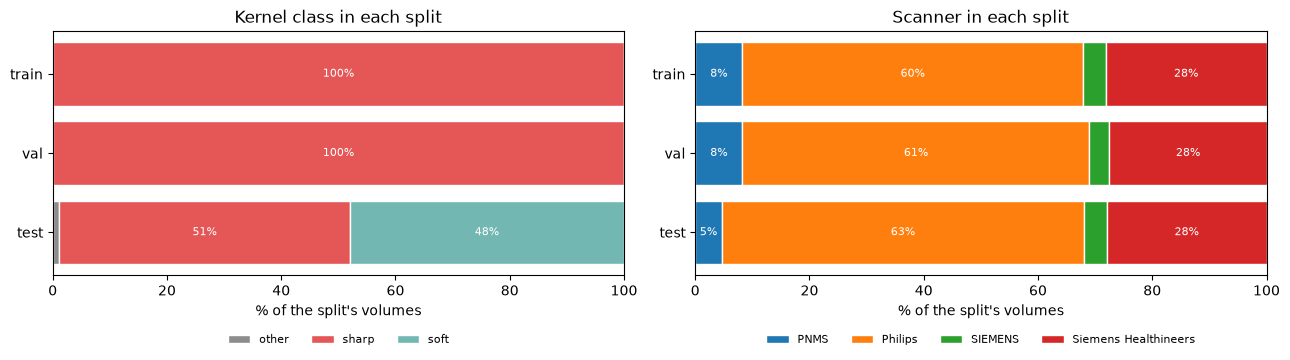

In [13]:
overview = man.groupby("split").agg(volumes=("volume_id", "size"), scans=("scan_key", "nunique"),
                                    patients=("patient_id", "nunique")).reindex(SPLITS)
overview["% of volumes"] = (100 * overview.volumes / overview.volumes.sum()).round(1)
display(overview)

kernel_ct = pd.crosstab(man.split, man.kernel_class).reindex(SPLITS)
scanner_ct = pd.crosstab(man.split, man.manufacturer).reindex(SPLITS)
for name, ct in [("kernel class", kernel_ct), ("scanner", scanner_ct)]:
    print(f"volumes by {name}: count, then % of the split")
    display(pd.concat({"volumes": ct, "% of split": pct_of_split(ct).round(1)}, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
stacked_bars(axes[0], pct_of_split(kernel_ct), CLASS_COLOR, "Kernel class in each split")
stacked_bars(axes[1], pct_of_split(scanner_ct), dict(zip(scanner_ct.columns, plt.cm.tab10.colors)), "Scanner in each split")
plt.tight_layout()
plt.show()

### 6.2 Convolution kernels

The raw `ConvolutionKernel` names behind the sharp / soft classes, as a share of each split. Kernels that train never saw
(for example `B`, `Br40f`) show up only in test -- that is the cross-kernel part of the evaluation.

split,class,train n,val n,test n,train %,val %,test %
kernel,,,,,,,
YA,sharp,2923,590,779,50.2,50.1,25.7
Br60f,sharp,1003,202,239,17.2,17.1,7.9
Bl56f,sharp,638,122,180,10.9,10.4,5.9
B,soft,0,0,851,0.0,0.0,28.0
EA,sharp,478,97,125,8.2,8.2,4.1
L,sharp,311,60,93,5.3,5.1,3.1
Br40f,soft,0,0,425,0.0,0.0,14.0
YB,sharp,237,66,65,4.1,5.6,2.1
Bl57d,sharp,217,41,59,3.7,3.5,1.9


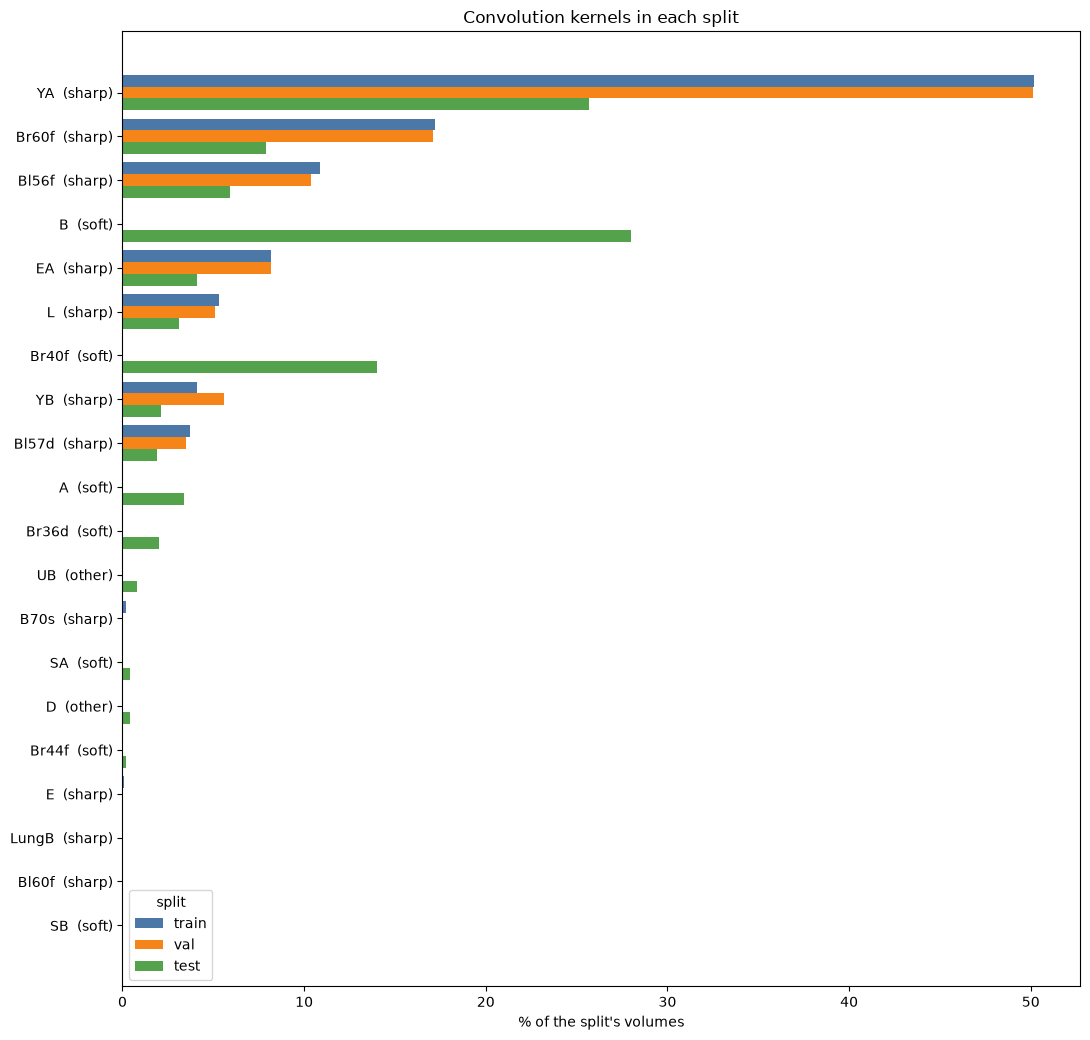

In [14]:
by_kernel = pd.crosstab(man.kernel, man.split).reindex(columns=SPLITS)
kernels = by_kernel.add_suffix(" n").join(by_kernel.div(by_kernel.sum()).mul(100).round(1).add_suffix(" %"))
kernels.insert(0, "class", man.drop_duplicates("kernel").set_index("kernel").kernel_class.reindex(kernels.index))
kernels = kernels.assign(total=by_kernel.sum(axis=1)).sort_values("total", ascending=False).drop(columns="total")
display(kernels)

fig, ax = plt.subplots(figsize=(11, 0.45 * len(kernels) + 1.5))
y, h = np.arange(len(kernels)), 0.27
for k, s in enumerate(SPLITS):
    ax.barh(y + (k - 1) * h, kernels[f"{s} %"], h, label=s, color=SPLIT_COLOR[s])
ax.set_yticks(y, [f"{k}  ({c})" for k, c in zip(kernels.index, kernels["class"])])
ax.invert_yaxis()
ax.set_xlabel("% of the split's volumes")
ax.set_title("Convolution kernels in each split")
ax.legend(title="split")
plt.tight_layout()
plt.show()

### 6.3 How common is each finding in each split

Left: percent of volumes that carry the finding. Right: how far val and test are from train, in percentage points (a bar to the
right means more common than in train). `pos_weight` is the number of negatives per positive in train, ready for
`BCEWithLogitsLoss(pos_weight=...)`; the rare findings at the bottom are the ones to watch for.

,train %,val %,test %,all %,train n,val n,test n,val - train,test - train,pos_weight
Lung nodule,46.6,44.1,44.7,45.8,2717,519,1359,-2.6,-1.9,1.14
Lung opacity,36.1,36.2,39.0,37.0,2106,426,1183,0.0,2.8,1.77
Arterial wall calcification,28.6,25.6,28.5,28.2,1669,301,866,-3.1,-0.1,2.49
Pulmonary fibrotic sequela,26.3,26.3,27.4,26.6,1535,310,831,-0.0,1.0,2.80
Coronary artery wall calcification,25.9,23.2,25.2,25.4,1510,273,764,-2.7,-0.8,2.86
Atelectasis,25.6,24.6,23.4,24.8,1491,290,712,-1.0,-2.1,2.91
Lymphadenopathy,25.4,24.4,25.9,25.5,1482,287,788,-1.1,0.5,2.93
Emphysema,19.5,18.8,19.7,19.5,1136,222,599,-0.6,0.2,4.13
Consolidation,16.4,17.6,19.1,17.4,957,207,581,1.1,2.7,5.09
Hiatal hernia,14.1,13.5,13.7,13.9,822,159,416,-0.6,-0.4,6.09


percent of the split's volumes that carry the finding; 'val - train' and 'test - train' are percentage points; pos_weight = negatives per positive in train
largest train-vs-test gap: Lung opacity (+2.8 points)


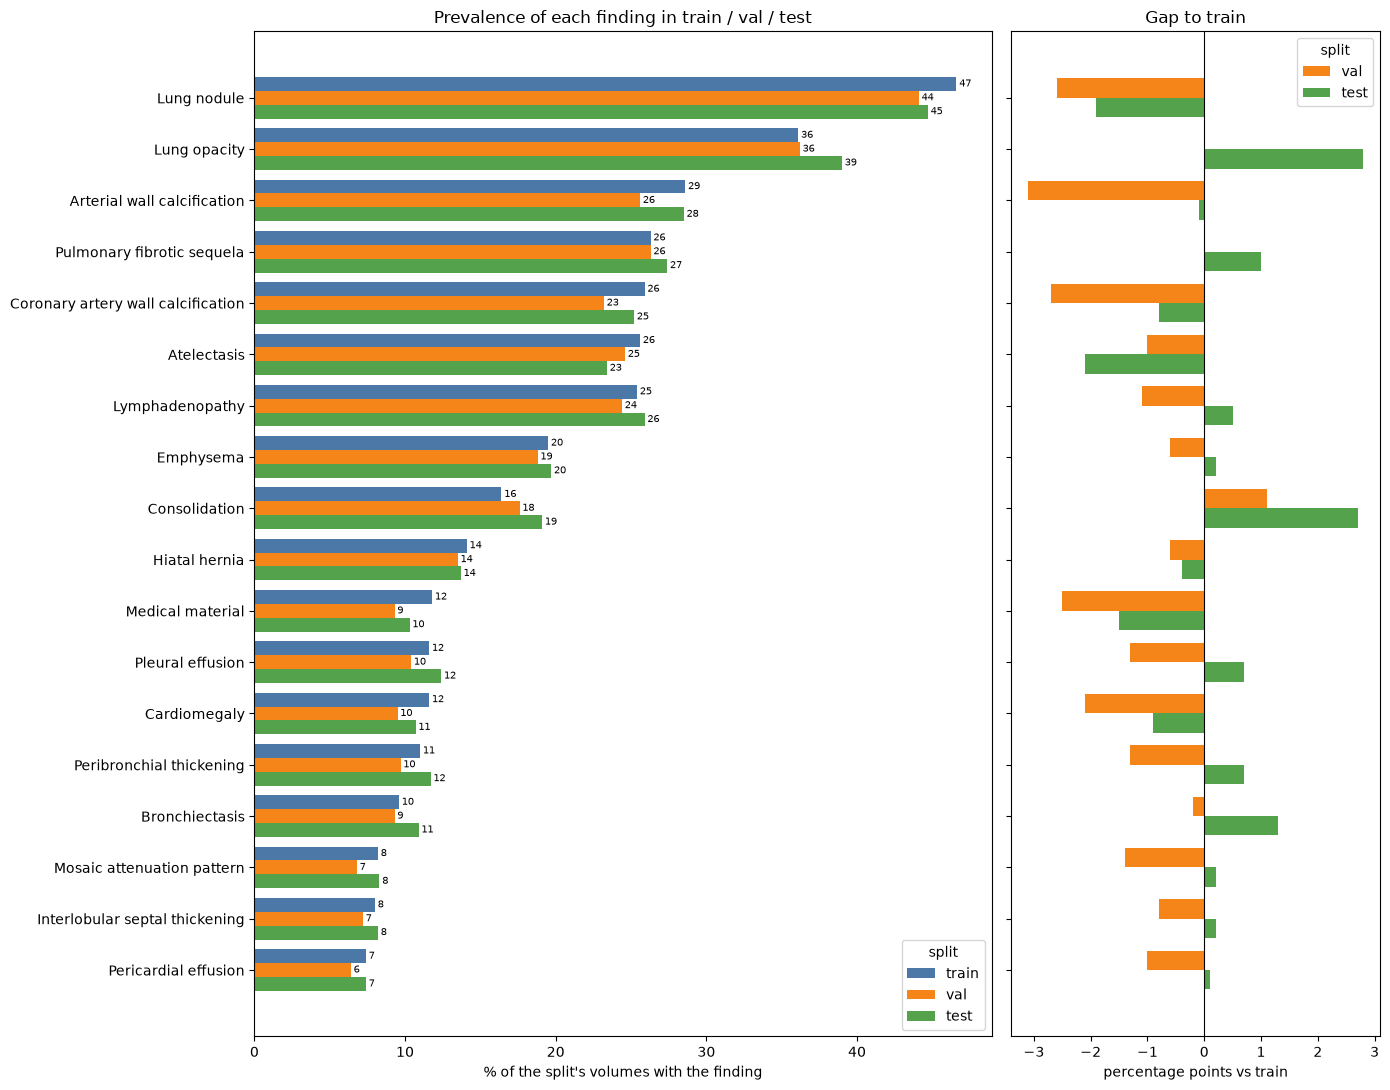

In [15]:
pos = man.groupby("split")[lab_cols].sum().T.reindex(columns=SPLITS)
prev = man.groupby("split")[lab_cols].mean().T.mul(100).reindex(columns=SPLITS)
prevalence = pd.DataFrame({
    "train %": prev.train, "val %": prev.val, "test %": prev.test,
    "all %": man[lab_cols].mean().mul(100),
    "train n": pos.train, "val n": pos.val, "test n": pos.test,
    "val - train": prev.val - prev.train, "test - train": prev.test - prev.train,
    "pos_weight": (100 - prev.train) / prev.train,  # negatives per positive in train, e.g. for BCEWithLogitsLoss
}).rename(index=nice).sort_values("train %", ascending=False)
prevalence = prevalence.round({"train %": 1, "val %": 1, "test %": 1, "all %": 1, "val - train": 1, "test - train": 1, "pos_weight": 2})
display(prevalence)
print("percent of the split's volumes that carry the finding; 'val - train' and 'test - train' are percentage points; "
      "pos_weight = negatives per positive in train")
print(f"largest train-vs-test gap: {prevalence['test - train'].abs().idxmax()} ({prevalence['test - train'].loc[prevalence['test - train'].abs().idxmax()]:+.1f} points)")

order = prevalence.index[::-1]  # barh draws the first row at the bottom
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 0.5 * len(order) + 2), sharey=True, gridspec_kw={"width_ratios": [2, 1]})
y, h = np.arange(len(order)), 0.27
for k, s in enumerate(SPLITS):
    bars = a1.barh(y + (1 - k) * h, prevalence.loc[order, f"{s} %"], h, label=s, color=SPLIT_COLOR[s])
    a1.bar_label(bars, fmt="%.0f", fontsize=7, padding=2)
a1.set_yticks(y, order)
a1.set_xlabel("% of the split's volumes with the finding")
a1.set_title("Prevalence of each finding in train / val / test")
a1.legend(title="split", loc="lower right")
for k, s in enumerate(["val", "test"]):
    a2.barh(y + (0.5 - k) * h * 1.4, prevalence.loc[order, f"{s} - train"], h * 1.4, label=s, color=SPLIT_COLOR[s])
a2.axvline(0, color="black", lw=0.8)
a2.set_xlabel("percentage points vs train")
a2.set_title("Gap to train")
a2.legend(title="split")
plt.tight_layout()
plt.show()

### 6.4 The same, by split and kernel class

Only groups with at least 100 volumes are shown (the 36 `other`-kernel test volumes are too few to read a percentage from).
If `test sharp` and `test soft` are close, the finding does not depend on the kernel; if `test` is far from `train`, the gap is a
change of patients, not of kernel.

,train sharp (n=5827),val sharp (n=1178),test sharp (n=1542),test soft (n=1459)
Lung nodule,46.6,44.1,44.7,45.2
Lung opacity,36.1,36.2,38.6,39.9
Arterial wall calcification,28.6,25.6,27.8,29.1
Pulmonary fibrotic sequela,26.3,26.3,27.2,27.6
Coronary artery wall calcification,25.9,23.2,24.5,26.0
Atelectasis,25.6,24.6,23.1,23.8
Lymphadenopathy,25.4,24.4,25.4,26.2
Emphysema,19.5,18.8,19.6,19.7
Consolidation,16.4,17.6,18.9,19.6
Hiatal hernia,14.1,13.5,13.9,13.8


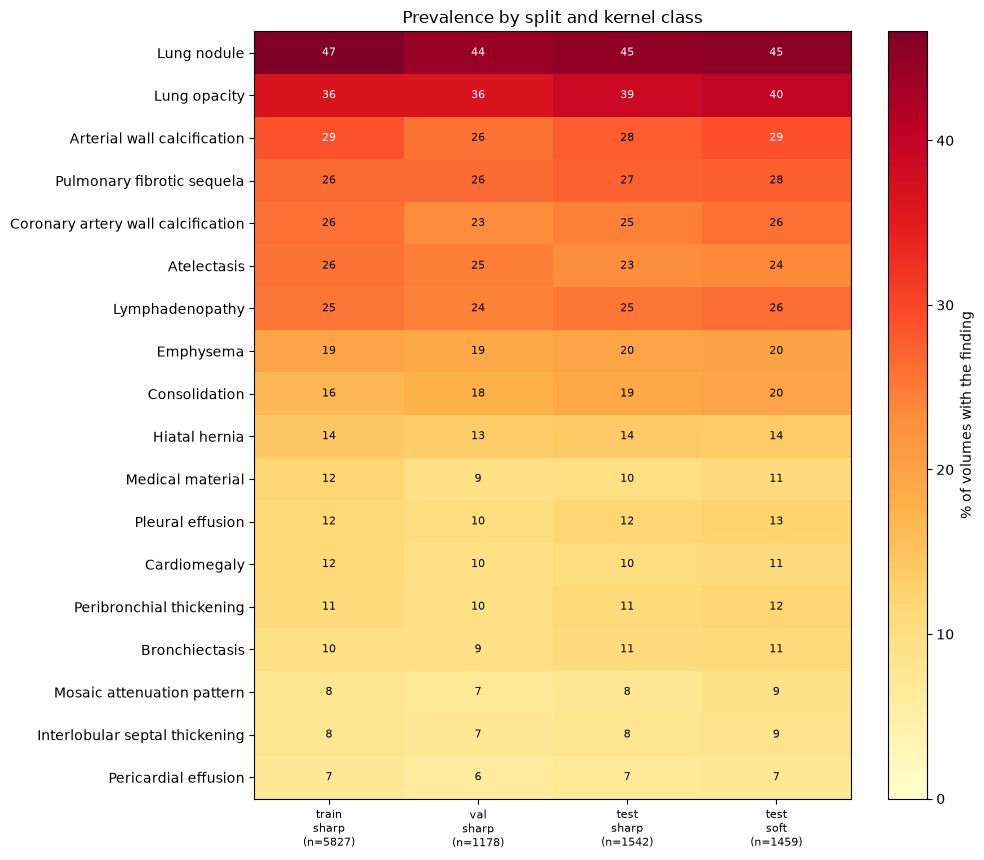

In [16]:
groups = man.groupby(["split", "kernel_class"])
sizes = groups.size()
sizes = sizes[sizes >= 100].reindex([(s, k) for s in SPLITS for k in ["sharp", "soft", "other"]]).dropna().astype(int)  # a few volumes say nothing
grp_prev = groups[lab_cols].mean().mul(100).loc[sizes.index].T.rename(index=nice)
grp_prev.columns = [f"{s}\n{k}\n(n={sizes[(s, k)]})" for s, k in grp_prev.columns]
grp_prev = grp_prev.loc[prevalence.index]
display(grp_prev.round(1).rename(columns=lambda c: c.replace("\n", " ")))

fig, ax = plt.subplots(figsize=(1.3 * grp_prev.shape[1] + 5, 0.4 * len(grp_prev) + 1.5))
im = ax.imshow(grp_prev.to_numpy(), cmap="YlOrRd", aspect="auto", vmin=0)
ax.set_xticks(range(grp_prev.shape[1]), grp_prev.columns, fontsize=8)
ax.set_yticks(range(len(grp_prev)), grp_prev.index)
for i in range(grp_prev.shape[0]):
    for j in range(grp_prev.shape[1]):
        v = grp_prev.iat[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if v > 0.6 * grp_prev.to_numpy().max() else "black")
fig.colorbar(im, ax=ax, label="% of volumes with the finding")
ax.set_title("Prevalence by split and kernel class")
plt.tight_layout()
plt.show()

### 6.5 How many findings does a volume carry?

This is a multi-label problem: a volume with no finding and a volume with five look very different to a model. The `5+` bar groups
everything from five findings up.

% of split                              
findings per volume          0     1     2     3     4    5+
split                                                       
train                     11.6  17.3  16.3  13.5   9.7  31.6
val                       13.0  18.4  17.1  12.2  10.6  28.7
test                      11.4  16.8  15.7  13.4  11.4  31.3

,mean,median,max
split,,,
train,3.44,3.0,13
val,3.23,3.0,14
test,3.47,3.0,12


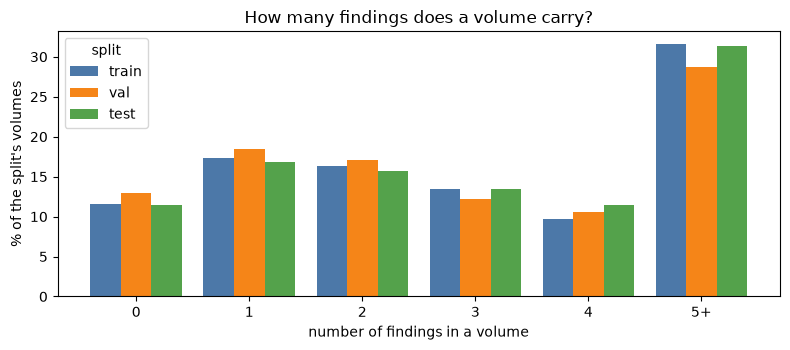

In [17]:
n_pos = man[lab_cols].sum(axis=1).clip(upper=5).map(lambda n: "5+" if n >= 5 else str(int(n)))
per_vol = pct_of_split(pd.crosstab(man.split, n_pos).reindex(SPLITS)).round(1)
per_vol.columns.name = "findings per volume"
display(pd.concat({"% of split": per_vol, }, axis=1))
stats = man.assign(n=man[lab_cols].sum(axis=1)).groupby("split").n.agg(mean="mean", median="median", max="max").reindex(SPLITS).round(2)
display(stats)

fig, ax = plt.subplots(figsize=(8, 3.6))
x, w = np.arange(per_vol.shape[1]), 0.27
for k, s in enumerate(SPLITS):
    ax.bar(x + (k - 1) * w, per_vol.loc[s], w, label=s, color=SPLIT_COLOR[s])
ax.set_xticks(x, per_vol.columns)
ax.set_xlabel("number of findings in a volume")
ax.set_ylabel("% of the split's volumes")
ax.set_title("How many findings does a volume carry?")
ax.legend(title="split")
plt.tight_layout()
plt.show()

## How to read this

- **Few labels flagged, small spreads:** scanner and finding are mostly independent -- sharp-only training is a clean choice.
- **A finding that follows a scanner** (for example one scanner with far more pleural effusion): report accuracy per scanner group
  as well as overall, and consider balancing the sampling by scanner.
- **Skipped scans clearly different:** consider whether to keep them (`train_kernel` takes only scans that have the kernel; a separate run with the other kernel can add them).
- **A finding much rarer in val or test than in train (section 6.3), or a split with a different scanner / kernel mix:** its score is measured on
  a different population, so compare per group and look at `pos_weight` for the rare findings before trusting a single average.